# Experiment 01: Calculation of Doppler Shift and Maximum Mobile Velocity

**Course:** Mobile and Cellular Communication Laboratory  
**Course Code:** ICT-4204  
**Department:** Department of Information and Communication Technology, Islamic University, Kushtia, Bangladesh  
**Implementation:** Python / Jupyter Notebook

---
**Course-source basis:** ICT-4204 Practical Experiment Assignment; previous-year Doppler question; William C. Y. Lee reference text for mobile-channel context.

> This notebook is an educational laboratory implementation. It keeps the mathematical model simple enough to explain in a practical examination while preserving the core cellular-communication ideas.

## Aim

To calculate Doppler shift for a moving mobile terminal and to determine the maximum mobile velocity for a specified maximum Doppler frequency.

## Objectives

- Understand why relative motion changes the received carrier frequency.
- Relate carrier frequency, wavelength, velocity, and direction of motion.
- Calculate maximum Doppler shift.
- Recover mobile velocity from a measured maximum Doppler shift.
- Visualize how Doppler shift varies with angle and mobile speed.

## Theory

When a mobile terminal moves relative to the direction of arrival of a radio wave, the received carrier is shifted in frequency. This is the **Doppler effect**. Motion **toward** the arriving wave produces a positive shift, while motion **away** produces a negative shift.

The wavelength of a carrier is

$$
\lambda = \frac{c}{f_c}
$$

where:

- $c \approx 3\times 10^8$ m/s is the speed of light,
- $f_c$ is the carrier frequency in hertz,
- $\lambda$ is the wavelength in metres.

For a mobile moving with speed $v$, the Doppler shift of one arriving path is modeled by

$$
f_d = \frac{v}{\lambda}\cos\theta
$$

or, after substituting $\lambda=c/f_c$,

$$
f_d = \frac{v f_c}{c}\cos\theta
$$

where $\theta$ is the angle between the mobile velocity vector and the direction of arrival of the wave.

The **maximum magnitude** of Doppler shift occurs when $|\cos\theta|=1$:

$$
f_m = \frac{v}{\lambda} = \frac{v f_c}{c}
$$

Therefore, if $f_m$ is known, the corresponding maximum mobile velocity is

$$
v_{\max} = \frac{f_m c}{f_c}
$$

> The practical assignment names this Doppler experiment. The analytical equations above are the standard narrowband Doppler relationships used to implement that assigned task.

## Important Terminology

| Term | Meaning |
|---|---|
| Carrier frequency $f_c$ | Nominal transmitted RF carrier frequency |
| Wavelength $\lambda$ | Physical length of one carrier cycle in free space |
| Mobile speed $v$ | Speed of the mobile terminal |
| Doppler shift $f_d$ | Change in received frequency caused by motion |
| Maximum Doppler $f_m$ | Largest possible magnitude of Doppler shift for a given speed |
| Arrival angle $\theta$ | Angle between motion and wave arrival direction |

## Procedure

1. Choose carrier frequency and mobile speed.
2. Convert speed from km/h to m/s.
3. Calculate wavelength.
4. Calculate maximum Doppler shift.
5. Evaluate Doppler shift for angles from $0^\circ$ to $360^\circ$.
6. Plot Doppler shift versus angle.
7. Repeat the maximum-shift calculation over a range of mobile speeds.
8. Invert the equation to estimate velocity from a measured $f_m$.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

c = 3e8  # speed of light (m/s)

# Configurable parameters
carrier_frequency_hz = 900e6
mobile_speed_kmh = 72.0

mobile_speed_ms = mobile_speed_kmh / 3.6
wavelength_m = c / carrier_frequency_hz
max_doppler_hz = mobile_speed_ms / wavelength_m

print(f"Carrier frequency : {carrier_frequency_hz/1e6:.1f} MHz")
print(f"Mobile speed      : {mobile_speed_kmh:.1f} km/h = {mobile_speed_ms:.2f} m/s")
print(f"Wavelength        : {wavelength_m:.4f} m")
print(f"Maximum Doppler   : {max_doppler_hz:.2f} Hz")

Carrier frequency : 900.0 MHz
Mobile speed      : 72.0 km/h = 20.00 m/s
Wavelength        : 0.3333 m
Maximum Doppler   : 60.00 Hz


### Numerical Example

With $f_c=900$ MHz and $v=72$ km/h:

$$
v = \frac{72}{3.6}=20\text{ m/s}
$$

$$
\lambda=\frac{3\times10^8}{900\times10^6}\approx0.333\text{ m}
$$

and

$$
f_m=\frac{20}{0.333}\approx60\text{ Hz}
$$

The code above should therefore report approximately **60 Hz**.

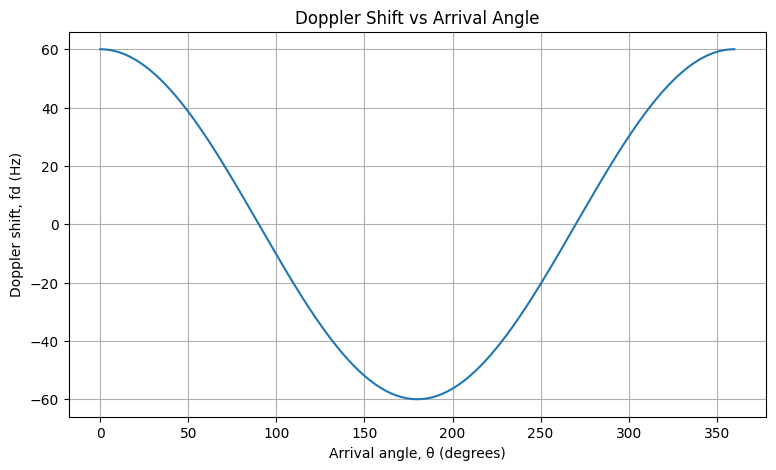

In [2]:
angles_deg = np.linspace(0, 360, 361)
doppler_hz = max_doppler_hz * np.cos(np.deg2rad(angles_deg))

plt.figure(figsize=(9, 5))
plt.plot(angles_deg, doppler_hz)
plt.xlabel("Arrival angle, θ (degrees)")
plt.ylabel("Doppler shift, fd (Hz)")
plt.title("Doppler Shift vs Arrival Angle")
plt.grid(True)
plt.show()

**Observation:** The shift is maximum positive at $0^\circ$, zero at $90^\circ$ and $270^\circ$, and maximum negative at $180^\circ$. Thus the same mobile speed can produce different Doppler shifts depending on direction.

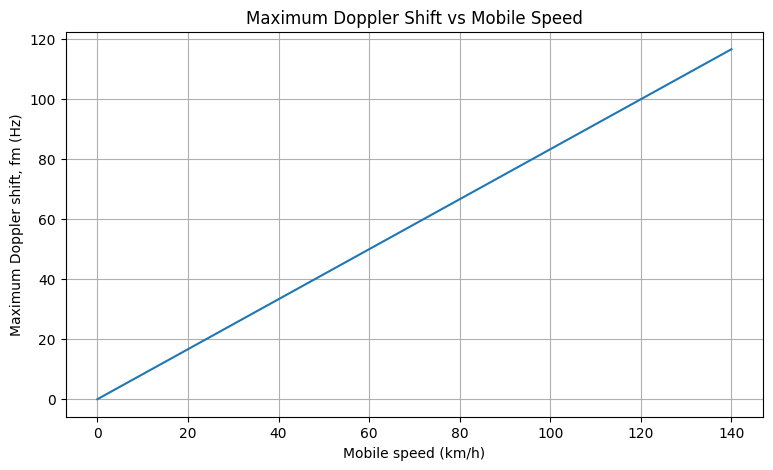

In [3]:
speeds_kmh = np.linspace(0, 140, 141)
speeds_ms = speeds_kmh / 3.6
max_doppler_vs_speed = speeds_ms * carrier_frequency_hz / c

plt.figure(figsize=(9, 5))
plt.plot(speeds_kmh, max_doppler_vs_speed)
plt.xlabel("Mobile speed (km/h)")
plt.ylabel("Maximum Doppler shift, fm (Hz)")
plt.title("Maximum Doppler Shift vs Mobile Speed")
plt.grid(True)
plt.show()

**Observation:** For a fixed carrier frequency, maximum Doppler shift increases linearly with mobile speed.

In [4]:
measured_max_doppler_hz = 100.0
estimated_speed_ms = measured_max_doppler_hz * c / carrier_frequency_hz
estimated_speed_kmh = estimated_speed_ms * 3.6

print(f"For a measured maximum Doppler of {measured_max_doppler_hz:.1f} Hz:")
print(f"Estimated speed = {estimated_speed_ms:.2f} m/s")
print(f"Estimated speed = {estimated_speed_kmh:.2f} km/h")

For a measured maximum Doppler of 100.0 Hz:
Estimated speed = 33.33 m/s
Estimated speed = 120.00 km/h


## Result and Discussion

The experiment demonstrates that Doppler shift depends on three main quantities: carrier frequency, mobile speed, and direction of motion. A higher carrier frequency or a higher speed produces a larger maximum Doppler shift. The angular plot also shows why a multipath mobile channel may contain several Doppler components at the same time.

## Conclusion

Doppler shift was calculated successfully using the standard mobile-radio relationship. The inverse relationship was also used to estimate maximum mobile velocity from a known Doppler frequency.

## Viva Questions and Short Answers

1. **What causes Doppler shift?**  
   Relative motion between the mobile and the arriving radio wave.

2. **When is Doppler shift maximum?**  
   When the motion is directly toward or directly away from the wave direction.

3. **What is the Doppler shift at $\theta=90^\circ$?**  
   Zero, because $\cos90^\circ=0$.

4. **What happens to Doppler shift if carrier frequency increases?**  
   Its magnitude increases for the same mobile speed.

5. **What is maximum Doppler frequency?**  
   The largest magnitude of Doppler shift possible for the given speed and carrier frequency.